In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip uninstall -y numpy scipy
!pip install numpy==2.2.6 scipy==1.16.3

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 89.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 59.3 MB/s eta 0:00:00:00:010:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.

In [ ]:
!pip uninstall pytorch-lightning -y
!pip uninstall lightning -y
!pip uninstall lightning-fabric -y

!pip install lightning==2.2.1
!pip install terratorch --upgrade

Found existing installation: pytorch-lightning 2.6.1
Uninstalling pytorch-lightning-2.6.1:
  Successfully uninstalled pytorch-lightning-2.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 55.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspec-2026.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [ ]:
import os
os._exit(0)

In [ ]:
import sys
!{sys.executable} -m pip install terratorch

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import rasterio
import matplotlib.pyplot as plt

import albumentations
from albumentations.pytorch import ToTensorV2

import terratorch
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
BASE_PATH = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data"

IMAGE_PATH = os.path.join(BASE_PATH, "image")
LABEL_PATH = os.path.join(BASE_PATH, "label")
PRED_PATH = os.path.join(BASE_PATH, "prediction")
SPLIT_PATH = os.path.join(BASE_PATH, "split")

print("Dataset folders:")
print(os.listdir(BASE_PATH))

Dataset folders:
['label', 'split', 'prediction', 'image']


In [3]:
image_files = sorted(os.listdir(IMAGE_PATH))
label_files = sorted(os.listdir(LABEL_PATH))

print("Total images:", len(image_files))
print("Total labels:", len(label_files))

print("\nSample image files:")
print(image_files[:5])

print("\nSample label files:")
print(label_files[:5])

Total images: 79
Total labels: 79

Sample image files:
['20240529_EO4_RES2_fl_pid_001_image.tif', '20240529_EO4_RES2_fl_pid_002_image.tif', '20240529_EO4_RES2_fl_pid_003_image.tif', '20240529_EO4_RES2_fl_pid_004_image.tif', '20240529_EO4_RES2_fl_pid_005_image.tif']

Sample label files:
['20240529_EO4_RES2_fl_pid_001_label.tif', '20240529_EO4_RES2_fl_pid_002_label.tif', '20240529_EO4_RES2_fl_pid_003_label.tif', '20240529_EO4_RES2_fl_pid_004_label.tif', '20240529_EO4_RES2_fl_pid_005_label.tif']


In [4]:
split_files = os.listdir(SPLIT_PATH)

print("Split files:")
print(split_files)

train_split = pd.read_csv(os.path.join(SPLIT_PATH,"train.txt"))
val_split = pd.read_csv(os.path.join(SPLIT_PATH,"val.txt"))
test_split = pd.read_csv(os.path.join(SPLIT_PATH,"test.txt"))

print("Train size:", len(train_split))
print("Validation size:", len(val_split))
print("Test size:", len(test_split))

Split files:
['pred.txt', 'val.txt', 'test.txt', '.ipynb_checkpoints', 'train.txt']
Train size: 58
Validation size: 9
Test size: 9


In [5]:
sample_image = os.path.join(IMAGE_PATH, image_files[0])

with rasterio.open(sample_image) as src:
    img = src.read()

print("Image shape:", img.shape)
print("Number of bands:", img.shape[0])

Image shape: (6, 512, 512)
Number of bands: 6


In [6]:
def compute_indices(img):
    hh = img[0]
    hv = img[1]
    green = img[2]
    nir = img[4]
    swir = img[5]

    ndwi = (green - nir) / (green + nir + 1e-6)
    mndwi = (green - swir) / (green + swir + 1e-6)
    sar_ratio = hh / (hv + 1e-6)

    return ndwi, mndwi, sar_ratio

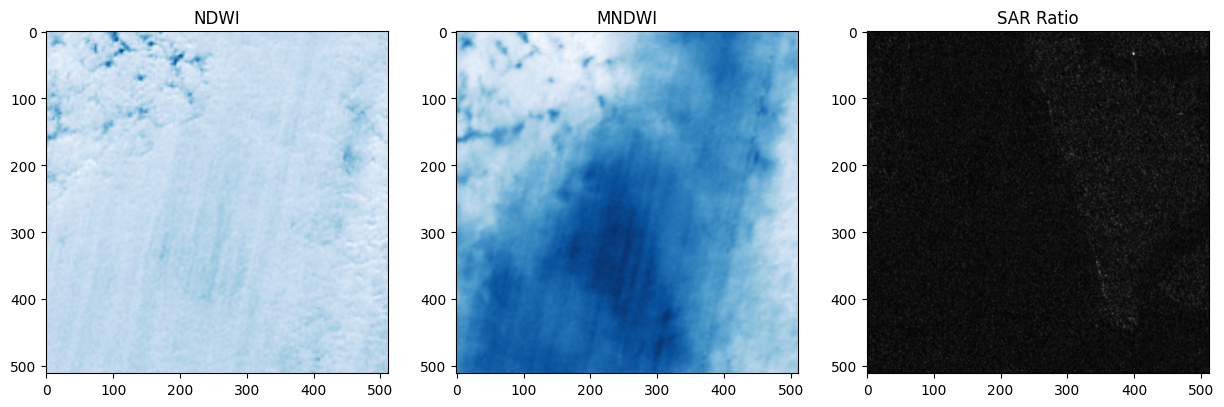

In [7]:
ndwi,mndwi,sar_ratio = compute_indices(img)

fig,axs = plt.subplots(1,3,figsize=(15,5))

axs[0].imshow(ndwi,cmap="Blues")
axs[0].set_title("NDWI")

axs[1].imshow(mndwi,cmap="Blues")
axs[1].set_title("MNDWI")

axs[2].imshow(sar_ratio,cmap="gray")
axs[2].set_title("SAR Ratio")

plt.show()

In [8]:
sample_label = os.path.join(LABEL_PATH, label_files[0])

with rasterio.open(sample_label) as src:
    mask = src.read(1)

print("Mask shape:", mask.shape)
print("Unique values:", np.unique(mask))   # should now show [0,1,2]

Mask shape: (512, 512)
Unique values: [0. 1. 2.]


In [9]:
counts = {0:0, 1:0, 2:0}

for f in label_files:
    with rasterio.open(os.path.join(LABEL_PATH, f)) as src:
        m = src.read(1)
        for c in [0,1,2]:
            counts[c] += np.sum(m == c)

total = sum(counts.values())

print("Pixel distribution:")
for k,v in counts.items():
    print(f"Class {k}: {v} ({v/total:.3f})")

Pixel distribution:
Class 0: 13589244 (0.656)
Class 1: 2794727 (0.135)
Class 2: 4325405 (0.209)


In [10]:
means = []
stds = []

for i in range(img.shape[0]):
    band = img[i].astype(np.float32)
    means.append(float(band.mean()))
    stds.append(float(band.std()))

print("Band means:", [round(m, 2) for m in means])
print("Band stds :", [round(s, 2) for s in stds])

# You can average over more images later if needed
global_means = [841.13, 371.62, 1734.18, 1588.31, 1742.85, 1218.56]   # your previous values
global_stds  = [473.71, 170.36, 623.05, 612.85, 564.58, 528.09]
print("\nUsing these global stats for normalization (update if you compute on full train set)")

Band means: [408.0, 187.54, 2062.27, 1929.6, 1954.99, 1333.92]
Band stds : [342.98, 136.58, 169.14, 159.76, 160.4, 139.73]

Using these global stats for normalization (update if you compute on full train set)


In [11]:
import albumentations as A

In [12]:
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=2,
    num_workers=2,
    num_classes=3,   # 🔥 CHANGED
    
    train_data_root=IMAGE_PATH,
    train_label_data_root=LABEL_PATH,
    val_data_root=IMAGE_PATH,
    val_label_data_root=LABEL_PATH,
    test_data_root=IMAGE_PATH,
    test_label_data_root=LABEL_PATH,
    
    train_split=os.path.join(SPLIT_PATH, "train.txt"),
    val_split=os.path.join(SPLIT_PATH, "val.txt"),
    test_split=os.path.join(SPLIT_PATH, "test.txt"),
    
    img_grep="*image.tif",
    label_grep="*label.tif",
    
    train_transform=[
        A.D4(p=1.0),
        A.RandomBrightnessContrast(p=0.4),
        A.RandomGamma(p=0.3),
        A.GaussianBlur(blur_limit=3, p=0.25),
        A.CoarseDropout(p=0.25),
        ToTensorV2()
    ],
    
    means=global_means,
    stds=global_stds,
    
    no_data_replace=0,
    no_label_replace=-1,
    
    predict_data_root=os.path.join(BASE_PATH, "prediction/image")
)

datamodule.setup("fit")

In [13]:
print("Train samples:", len(datamodule.train_dataset))
print("Validation samples:", len(datamodule.val_dataset))

Train samples: 59
Validation samples: 10


Sample 0 → Image: torch.Size([6, 512, 512]), Mask: torch.Size([512, 512])


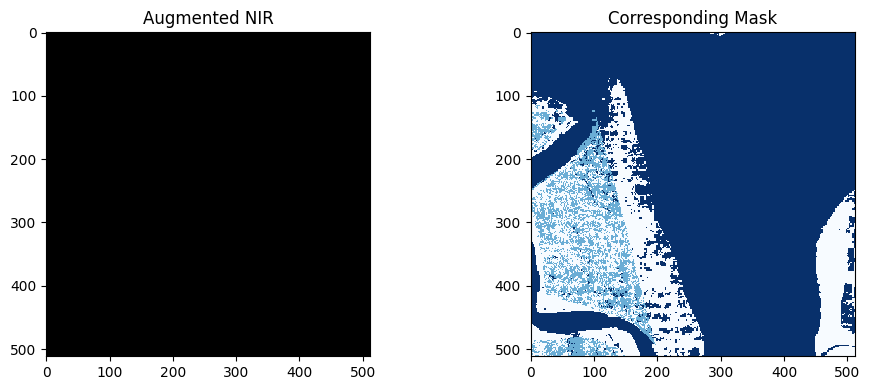

Sample 1 → Image: torch.Size([6, 512, 512]), Mask: torch.Size([512, 512])


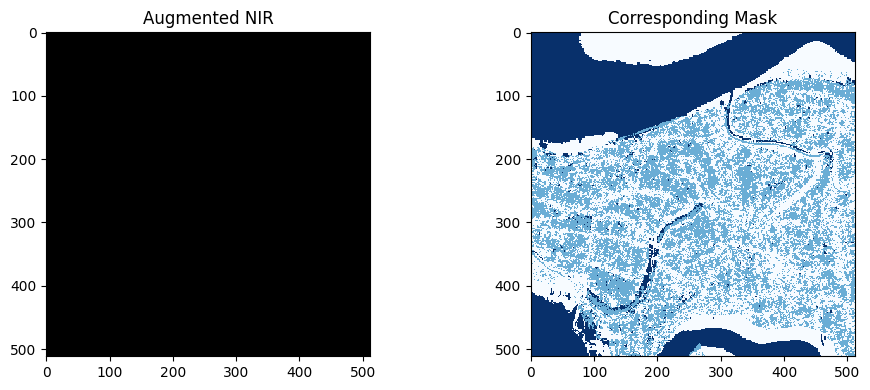

Sample 2 → Image: torch.Size([6, 512, 512]), Mask: torch.Size([512, 512])


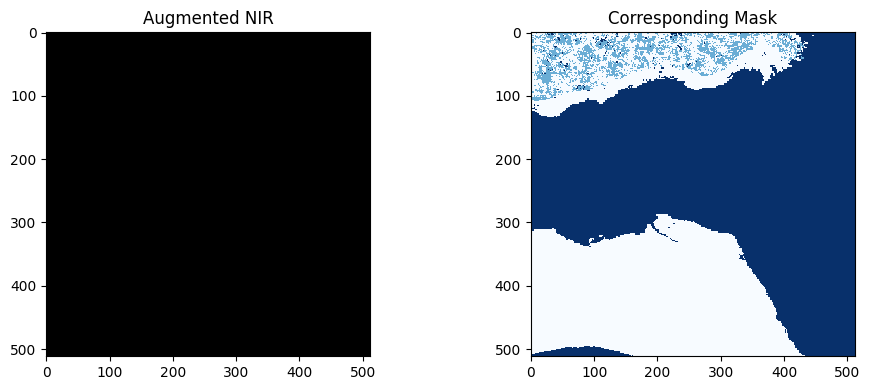

In [14]:
train_dataset = datamodule.train_dataset

for i in range(3):
    sample = train_dataset[i]
    image = sample["image"]      # torch tensor (C,H,W)
    mask  = sample["mask"]       # torch tensor (H,W)
    
    print(f"Sample {i} → Image: {image.shape}, Mask: {mask.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    # Show NIR band (index 3) as example
    nir = image[3].numpy()
    low, high = np.percentile(nir, (2, 98))
    nir = np.clip((nir - low) / (high - low + 1e-8), 0, 1)
    plt.imshow(nir, cmap="gray")
    plt.title("Augmented NIR")
    plt.subplot(1, 2, 2)
    plt.imshow(mask.numpy(), cmap="Blues", interpolation="nearest")
    plt.title("Corresponding Mask")
    plt.tight_layout()
    plt.show()

In [15]:
from huggingface_hub import list_repo_files

files = list_repo_files("ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11")
print(files)

2026-04-04 09:38:01,061 - INFO - HTTP Request: GET https://huggingface.co/api/models/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


['.gitattributes', 'Prithvi-EO-V2-300M-TL-Sen1Floods11.pt', 'README.md', 'config.json', 'config.yaml', 'examples/India_900498_S2Hand.tif', 'examples/Spain_7370579_S2Hand.tif', 'examples/USA_430764_S2Hand.tif', 'inference.py', 'requirements.txt']


In [16]:
column_name = train_split.columns[0]

counts = {0:0, 1:0, 2:0}

for fname in train_split[column_name]:
    path = os.path.join(LABEL_PATH, str(fname).strip() + "_label.tif")
    with rasterio.open(path) as src:
        mask = src.read(1)
        for c in [0,1,2]:
            counts[c] += np.sum(mask == c)

total = sum(counts.values())

class_weights = [
    total / (3 * counts[0] + 1e-6),
    total / (3 * counts[1] + 1e-6),
    total / (3 * counts[2] + 1e-6),
]

class_weights = [round(w,4) for w in class_weights]

print("Class weights:", class_weights)

Class weights: [np.float64(0.505), np.float64(2.1672), np.float64(1.7906)]


In [17]:
import torch
import lightning as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from huggingface_hub import hf_hub_download
from terratorch.tasks import SemanticSegmentationTask

In [18]:
model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        "backbone": "prithvi_eo_v2_300_tl",
        "backbone_pretrained": True,
        "backbone_num_frames": 1,
        "backbone_bands": ["HH", "HV", "GREEN", "RED", "NIR", "SWIR"],

        "necks": [
            {"name": "SelectIndices", "indices": [3, 7, 11, 15]},
            {"name": "ReshapeTokensToImage"},
            {"name": "LearnedInterpolateToPyramidal"},
        ],

        "decoder": "UNetDecoder",
        "decoder_channels": [512, 256, 128, 64],

        "head_dropout": 0.1,
        "num_classes": 3,   # 🔥 CHANGED
    },

    loss="ce",
    class_weights=class_weights,  # now 3 values
    optimizer="AdamW",
    lr=3e-5,

    ignore_index=-1,
    plot_on_val=True,

    class_names=['no flood', 'flood', 'water']   # 🔥 CHANGED
)

2026-04-04 09:38:05,235 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL/resolve/main/Prithvi_EO_V2_300M_TL.pt "HTTP/1.1 302 Found"
2026-04-04 09:38:05,236 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-04 09:38:05,326 - INFO - HTTP Request: GET https://huggingface.co/api/models/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL/xet-read-token/63adbd39c271da4c42f447e69b1a7c91a338cdc9 "HTTP/1.1 200 OK"


Prithvi_EO_V2_300M_TL.pt:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

In [19]:
from pytorch_lightning.loggers import TensorBoardLogger

In [20]:
OUT_DIR = "./outputs"

In [21]:
import os

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [22]:
from lightning.pytorch.callbacks import EarlyStopping

In [23]:
from lightning.pytorch.callbacks import LearningRateMonitor

In [24]:
EPOCHS = 50  # or whatever you want

In [25]:
import gc
torch.cuda.empty_cache()
gc.collect()

18162

In [26]:
from huggingface_hub import hf_hub_download

In [27]:
hf_model_id = "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11"

ckpt_path = hf_hub_download(
    repo_id=hf_model_id,
    filename="Prithvi-EO-V2-300M-TL-Sen1Floods11.pt",
)

checkpoint = torch.load(ckpt_path, map_location="cpu")
state_dict = checkpoint.get("state_dict", checkpoint)

model_dict = model.model.encoder.state_dict()

filtered_state_dict = {}

for k, v in state_dict.items():
    ck = k.replace("model.encoder.", "")
    
    if ck in model_dict and v.shape == model_dict[ck].shape:
        filtered_state_dict[ck] = v

print(f"✅ Matching layers: {len(filtered_state_dict)}")

model.model.encoder.load_state_dict(filtered_state_dict, strict=False)

print("🔥 Loaded Sen1Floods11 pretrained weights")

# =========================
# PARTIAL UNFREEZE
# =========================
for name, param in model.model.encoder.named_parameters():
    if "blocks" in name:
        try:
            block_num = int(name.split("blocks.")[1].split(".")[0])
            param.requires_grad = block_num >= 8
        except:
            param.requires_grad = False
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🔥 Trainable params: {trainable:,}")

# =========================
# LOGGER
# =========================
logger = TensorBoardLogger(
    save_dir=OUT_DIR,
    name="prithvi-burnscars",
    default_hp_metric=False
)

# =========================
# CALLBACKS
# =========================
checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename="best-{epoch:02d}-{val_mIoU:.4f}",
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
    verbose=True
)

early_stop = EarlyStopping(
    monitor="val/mIoU",
    patience=10,
    mode="max",
    min_delta=0.001,
    verbose=True
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

# =========================
# TRAINER
# =========================
trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    precision="16-mixed",
    max_epochs=EPOCHS,

    logger=logger,

    callbacks=[
        checkpoint_callback,
        early_stop,
        lr_monitor
    ],

    log_every_n_steps=5,
    enable_progress_bar=True,
    enable_model_summary=True,
    num_sanity_val_steps=0,
    gradient_clip_val=0.5,

    default_root_dir=OUT_DIR,
)

print("🚀 Ready to train!")

# =========================
# TRAIN
# =========================
trainer.fit(model, datamodule=datamodule)

2026-04-04 09:38:13,659 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/resolve/main/Prithvi-EO-V2-300M-TL-Sen1Floods11.pt "HTTP/1.1 302 Found"
2026-04-04 09:38:13,706 - INFO - HTTP Request: GET https://huggingface.co/api/models/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/xet-read-token/918b9f140bb1783716664a2421ea3253d806017d "HTTP/1.1 200 OK"


Prithvi-EO-V2-300M-TL-Sen1Floods11.pt:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

2026-04-04 09:38:20,097 - INFO - Using 16bit Automatic Mixed Precision (AMP)
2026-04-04 09:38:20,148 - INFO - GPU available: True (cuda), used: True
2026-04-04 09:38:20,148 - INFO - TPU available: False, using: 0 TPU cores
2026-04-04 09:38:20,150 - INFO - 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Matching layers: 295
🔥 Loaded Sen1Floods11 pretrained weights
🔥 Trainable params: 221,857,987
🚀 Ready to train!


2026-04-04 09:38:22.342670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775295502.527569     162 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775295502.588119     162 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775295503.023005     162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775295503.023043     162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775295503.023046     162 computation_placer.cc:177] computation placer alr

...

Trainable params: 221 M                                                                                            
Non-trainable params: 102 M                                                                                        
Total params: 324 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 649                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

2026-04-04 09:38:35,950 - INFO - Checking stackability for train split.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
2026-04-04 09:39:00,547 - INFO - Checking stackability for val split.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


RuntimeError: Given groups=1, weight of size [1024, 8, 1, 16, 16], expected input[2, 6, 1, 512, 512] to have 8 channels, but got 6 channels instead

In [ ]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

In [ ]:
import os
import torch
import numpy as np
import rasterio
from skimage.morphology import remove_small_objects, binary_closing, binary_opening
from scipy.ndimage import binary_fill_holes

# ────────────────────────────────────────────────
# Find best checkpoint
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
ckpt_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("best-")])
if ckpt_files:
    best_ckpt = os.path.join(CHECKPOINT_DIR, ckpt_files[-1])
    print("Best checkpoint:", best_ckpt)
else:
    best_ckpt = None
    print("No checkpoint found → using current model state")

In [ ]:
# ────────────────────────────────────────────────
# Setup datamodule
datamodule.setup("predict")
print("Running prediction...")

# Use weights_only=False to avoid unpickling issues
predictions = trainer.predict(
    model,
    datamodule=datamodule,
    ckpt_path=best_ckpt if best_ckpt else None,
    weights_only=False
)
print("Prediction done!")

In [ ]:
# Save predictions
output_dir = "/kaggle/working/prediction"
os.makedirs(output_dir, exist_ok=True)

for batch_idx, batch in enumerate(predictions):
    preds, file_paths = batch
    
    # Handle tuple outputs
    if isinstance(preds, tuple):
        preds = preds[0]
    
    # logits → class indices
    if preds.ndim == 4:
        preds = preds.argmax(dim=1)
    
    preds = preds.cpu().numpy().astype(np.uint8)
    
    for i in range(preds.shape[0]):
        mask = preds[i]
        
        # ──── POST-PROCESSING ────
        # Convert to boolean first (IMPORTANT)
        mask = mask.astype(bool)
        
        # Fill holes
        mask = binary_fill_holes(mask)
        
        # Remove small noise
        mask = remove_small_objects(mask, min_size=64)  # tune if needed
        
        # Morphological closing
        mask = binary_closing(mask, footprint=np.ones((3, 3)))
        
        # Convert back to uint8
        mask = mask.astype(np.uint8)
        
        # ──── SAVE ────
        ref_path = file_paths[i]
        
        with rasterio.open(ref_path) as src:
            meta = src.meta.copy()
        
        meta.update({
            "count": 1,
            "dtype": "uint8",
            "nodata": 255,
            "compress": "lzw"
        })
        
        out_name = os.path.basename(ref_path).replace("_image.tif", "_pred.tif")
        out_path = os.path.join(output_dir, out_name)
        
        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(mask, 1)
        
        print(f"Saved: {out_name}")

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path   # ✅ FIX

# ────────────────────────────────────────────────
# RLE function (unchanged, works fine)
def mask_to_rle(mask):
    pixels = mask.flatten(order="F").astype(np.uint8)
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)

# ────────────────────────────────────────────────
# Use same output_dir from prediction step
output_dir = "/kaggle/working/prediction"

rows = []
tif_dir = Path(output_dir)

for tif_path in sorted(tif_dir.glob("*_pred.tif")):
    with rasterio.open(tif_path) as src:
        mask = src.read(1)
    
    # Ensure binary (IMPORTANT)
    # Your pipeline outputs 0/1 already, but this keeps it safe
    mask_binary = (mask > 0).astype(np.uint8)
    
    # Generate RLE
    rle = mask_to_rle(mask_binary)
    
    image_id = tif_path.name.replace("_pred.tif", "")
    
    # 🔥 HANDLE EMPTY MASK
    if mask_binary.sum() == 0:
        # Option 1 (most common): empty string
        rle = "0 0"
        
        # Option 2 (if competition requires):
        # rle = "1 1"
    else:
        rle = mask_to_rle(mask_binary)
    
    image_id = tif_path.name.replace("_pred.tif", "")
    
    rows.append({
        "id": image_id,
        "rle_mask": rle
    })

# Create submission
submission = pd.DataFrame(rows)

save_path = "/kaggle/working/submission2.csv"
submission.to_csv(save_path, index=False)

print(f"Submission file created → {save_path}")
print(submission.head())